In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! unzip /content/drive/MyDrive/Dataset_BUSI_with_GT.zip

In [11]:
import os
import glob
import torch
import numpy as np
import pandas as pd
from torch import nn
from PIL import Image
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import Dataset , random_split , DataLoader
from typing import List, Tuple, Optional


/home/roshan/.local/lib/python3.10/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [12]:
image_size = 128
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [15]:
class BUSIDataset(Dataset):
    def __init__(self, root_dir: str = "./dataset/Dataset_BUSI_with_GT", image_transform=None):
        super().__init__()
        self.root_dir = root_dir
        self.image_transform = image_transform

        # Class mapping
        self.class_map = {"normal": 0, "benign": 1, "malignant": 2}
        self.samples = self._load_dataset()

    def _load_dataset(self):
        data = []
        for class_name, label in self.class_map.items():
            image_paths = glob.glob(os.path.join(self.root_dir, class_name, "*.png"))
            # Exclude mask files
            image_paths = [p for p in image_paths if "_mask" not in p]
            for img_path in image_paths:
                data.append((img_path, label))
        return pd.DataFrame(data, columns=["image_path", "label"])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        row = self.samples.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")  # 3 channels
        if self.image_transform:
            img = self.image_transform(img)
        label = torch.tensor(row["label"], dtype=torch.long)
        return img, label


# === Define Transforms ===
image_size = 224  # or your preferred input size
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # typical ImageNet normalization
                         std=[0.229, 0.224, 0.225]),
])

# === Initialize Dataset ===
dataset = BUSIDataset(root_dir="./Dataset_BUSI_with_GT", image_transform=transform)


train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_data, batch_size=10, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=10, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=10, shuffle=False, num_workers=2)



In [16]:
# SECNet implementation
# Self-Evolving Cross-Domain Cancer Intelligence Network (SECNet)
# Implements: CBAM-based encoder (adapted from user's original model) +
# Adaptive Attention Evolution Unit (AAEU) + Uncertainty-driven Counterfactual Refinement (UCR)
# Output: classification head (binary/multi-class)


# -------------------------
# Attention modules (expose maps)
# -------------------------
class ChannelAttention(nn.Module):
    def __init__(self, channel: int, reduction: int = 16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channel, channel // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channel // reduction, channel, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        attn = self.sigmoid(out)  # shape (B, C, 1, 1)
        return x * attn, attn

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn = self.sigmoid(out)  # shape (B, 1, H, W)
        return x * attn, attn

class CBAM(nn.Module):
    """CBAM that returns both attended output and attention maps for evolution controller."""
    def __init__(self, channel: int, reduction: int = 16, kernel_size: int = 7):
        super().__init__()
        self.ca = ChannelAttention(channel, reduction)
        self.sa = SpatialAttention(kernel_size)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, dict]:
        out_ca, attn_c = self.ca(x)
        out_sa, attn_s = self.sa(out_ca)
        attn_map = {"channel": attn_c, "spatial": attn_s}
        return out_sa, attn_map


# -------------------------
# Block encoder (adapted)
# -------------------------
class BlockEncoder(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
        dropout: float = 0.1,
        maxpooling: bool = True,
        inedxing: int = 0,
    ) -> None:
        super().__init__()
        self._maxpooling = maxpooling
        self._dropout = dropout

        self.initial_layers = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        self.indexed_layers = nn.ModuleList()
        for _ in range(inedxing):
            self.indexed_layers.append(nn.Sequential(
                nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                CBAM(out_channels),
                nn.Dropout(dropout),
            ))


        self._maxpool = nn.Sequential(nn.MaxPool2d(kernel_size=2), nn.Dropout(dropout))

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, Optional[torch.Tensor], dict]:
        """Returns: processed features, pooled features (or None), attention maps dict (list of maps aggregated)
        attention maps aggregated are for each CBAM inside this block; if none present, empty dicts returned as zeros.
        """
        attn_col = {"channel": [], "spatial": []}

        out = self.initial_layers(x)

        # Manually process indexed layers to handle CBAM output
        for seq in self.indexed_layers:
            # Iterate through modules in the sequential
            temp_out = out
            temp_attn = None
            for module in seq:
                if isinstance(module, CBAM):
                    temp_out, temp_attn = module(temp_out)
                else:
                    temp_out = module(temp_out)
            out = temp_out
            if temp_attn is not None:
                 attn_col["channel"].append(temp_attn["channel"])  # each is (B,C,1,1)
                 attn_col["spatial"].append(temp_attn["spatial"])  # each is (B,1,H,W)


        pooled = self._maxpool(out) if self._maxpooling else None
        # If no CBAM found, return single zero maps for shape consistency
        if len(attn_col["channel"]) == 0:
            attn_col = {"channel": None, "spatial": None}
        else:
            # concatenate along a new dimension (num_cbams)
            attn_col["channel"] = torch.stack(attn_col["channel"], dim=1)  # (B, N, C,1,1)
            attn_col["spatial"] = torch.stack(attn_col["spatial"], dim=1)  # (B, N,1,H,W)

        return out, pooled, attn_col


# -------------------------
# Adaptive Attention Evolution Unit (AAEU)
# -------------------------
class AAEU(nn.Module):
    """Learns to evolve attention maps over epochs/steps and modulate features.
    It takes previous and current attention maps and returns modulation tensors to scale features.
    """
    def __init__(self, num_cbams: int = 1, channels: int = 64, spatial_h: int = 1, spatial_w: int = 1):
        super().__init__()
        # meta MLP for channel attention evolution
        self.channel_mlp = nn.Sequential(
            nn.Linear(channels * num_cbams, channels * num_cbams // 4),
            nn.ReLU(inplace=True),
            nn.Linear(channels * num_cbams // 4, channels * num_cbams),
            nn.Sigmoid(),
        )
        # spatial controller (small conv)
        self.spatial_conv = nn.Sequential(
            nn.Conv3d(1, 4, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(4, 1, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, prev_attn: dict, cur_attn: dict) -> dict:
        # prev_attn and cur_attn expected shapes: channel (B, N, C,1,1), spatial (B, N,1,H,W)
        mod = {}
        if prev_attn is None or cur_attn is None:
            return {"channel_mod": None, "spatial_mod": None}

        # Ensure inputs are dictionaries before accessing keys
        if not isinstance(prev_attn, dict) or not isinstance(cur_attn, dict):
            raise TypeError("prev_attn and cur_attn must be dictionaries")

        # Check if batch sizes match
        if prev_attn["channel"].size(0) != cur_attn["channel"].size(0):
             # Skip evolution for mismatched batch sizes (e.g., last batch of epoch)
             return {"channel_mod": None, "spatial_mod": None}


        # Channel evolution: compute delta and run MLP per batch
        delta_c = (cur_attn["channel"] - prev_attn["channel"]).squeeze(-1).squeeze(-1)  # (B, N, C)
        B, N, C = delta_c.shape
        # flatten N and C
        delta_flat = delta_c.view(B, -1)  # (B, N*C)
        ch_mod = self.channel_mlp(delta_flat)  # (B, N*C)
        ch_mod = ch_mod.view(B, N, C, 1, 1)  # broadcastable

        # Spatial evolution: stack along channel for conv3d (B,1,N,H,W)
        spatial_stack = (cur_attn["spatial"] - prev_attn["spatial"])  # (B,N,1,H,W)
        # move to (B,1,N,H,W)
        spatial_stack = spatial_stack.permute(0, 2, 1, 3, 4)  # (B,1,N,H,W)
        sp_mod = self.spatial_conv(spatial_stack)  # (B,1,N,H,W) - Corrected shape after Conv3d

        # Average across the number of CBAMs (N dimension, index 2) to get (B, 1, H, W)
        sp_mod = sp_mod.mean(dim=2, keepdim=True) # Resulting shape (B, 1, 1, H, W)
        sp_mod = sp_mod.squeeze(2) # Resulting shape (B, 1, H, W)


        mod["channel_mod"] = ch_mod
        mod["spatial_mod"] = sp_mod
        return mod


# -------------------------
# Uncertainty-driven Counterfactual Refinement (UCR)
# -------------------------
class CounterfactualGenerator(nn.Module):
    """Lightweight generator that perturbs features in uncertain regions.
    It operates on feature maps (not raw image pixels) and produces altered feature maps.
    """
    def __init__(self, in_channels: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, in_channels, kernel_size=1),
            nn.Tanh(),  # outputs residual in [-1,1]
        )

    def forward(self, feats: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # mask shape: (B,1,H,W) with values in [0,1] indicating where to apply counterfactual
        delta = self.net(feats)
        return feats + delta * mask


# -------------------------
# SECNet main model
# -------------------------
class SECNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 3,
        num_classes: int = 2,
        dim: int = 2,
        image_size: int = 224,
        device: torch.device = torch.device("cpu"),
    ) -> None:
        super().__init__()
        self.device = device
        self._dim = dim
        self.image_size = image_size

        # Encoder: adapt the multi-scale structure from original model but simplified for clarity
        self.enc0 = BlockEncoder(in_channels, 64, 3, inedxing=0) # maxpooling=True by default
        self.enc1 = BlockEncoder(64, 128, 3, inedxing=dim) # maxpooling=True by default
        self.enc2 = BlockEncoder(128, 256, 3, inedxing=dim) # maxpooling=True by default
        self.enc3 = BlockEncoder(256, 512, 3, inedxing=dim, maxpooling=False)


        # AAEU - we set num_cbams equal to inedxing per block for controller sizing
        # The spatial dimensions of the attention maps from enc3 are 28x28
        self.aaeu = AAEU(num_cbams=max(1, dim), channels=512, spatial_h=28, spatial_w=28)

        # Counterfactual generator operates on deepest features
        self.cf_gen = CounterfactualGenerator(in_channels=512, hidden=128)

        # Classification head
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

        # Keep a buffer for previous attention maps for evolution (initialized None)
        self.prev_attns = None

        # enable MC dropout by having dropout in classifier and cf_gen
        self._mc_dropout = nn.Dropout(0.3)

    def forward(self, x: torch.Tensor, evolve: bool = True, apply_counterfactual: bool = True
                ) -> Tuple[torch.Tensor, dict, Optional[torch.Tensor], Optional[torch.Tensor], Optional[dict]]:
        """Forward pass returning logits, attention maps, uncertainty map, counterfactual logits, and AAEU modulations.

        Parameters:
            evolve: if True, compute AAEU modulations (needs prev_attns across steps)
            apply_counterfactual: if True, generate counterfactuals (only during training)

        Returns:
            logits: model output scores (classification head)
            attn_maps: dictionary containing attention maps for all encoders
            uncertainty_map: spatial uncertainty map (or None if not computed)
            logits_cf: logits from counterfactual features (or None)
            mods: AAEU modulation dictionary (or None)
        """

        B = x.size(0)

        # Encoder forward with attention capture
        f0, p0, attn0 = self.enc0(x)
        # print("Shape after enc0 (f0):", f0.shape)
        # print("Shape after enc0 (p0):", p0.shape if p0 is not None else None)
        f1, p1, attn1 = self.enc1(p0 if p0 is not None else f0)
        # print("Shape after enc1 (f1):", f1.shape)
        # print("Shape after enc1 (p1):", p1.shape if p1 is not None else None)
        f2, p2, attn2 = self.enc2(p1 if p1 is not None else f1)
        # print("Shape after enc2 (f2):", f2.shape)
        # print("Shape after enc2 (p2):", p2.shape if p2 is not None else None)
        f3, p3, attn3 = self.enc3(p2 if p2 is not None else f2)
        # print("Shape after enc3 (f3):", f3.shape)
        # print("Shape after enc3 (p3):", p3.shape if p3 is not None else None)


        # Collect current attention summary
        cur_attns = {
            "enc0": attn0,
            "enc1": attn1,
            "enc2": attn2,
            "enc3": attn3,
        }

        # ---- AAEU Modulation Phase ----
        mods = None
        if evolve and self.prev_attns is not None:
            # Extract channel and spatial maps from the stored tuple for AAEU
            prev_enc3_attn = self.prev_attns.get("enc3", None)
            if prev_enc3_attn is not None:
                 # Reconstruct the dictionary format expected by AAEU
                 prev_attn_dict = {"channel": prev_enc3_attn[0], "spatial": prev_enc3_attn[1]}
            else:
                 prev_attn_dict = None

            cur_enc3_attn = cur_attns.get("enc3", None)
            if cur_enc3_attn is not None and cur_enc3_attn["channel"] is not None:
                 # Make sure cur_attn_dict has the same keys as prev_attn_dict for consistent delta calculation
                 cur_attn_dict = {"channel": cur_enc3_attn["channel"], "spatial": cur_enc3_attn["spatial"]}
            else:
                 cur_attn_dict = None


            mods = self.aaeu(prev_attn_dict, cur_attn_dict)

            # Apply evolved channel and spatial modulation
            if mods and mods.get("channel_mod") is not None:
                ch_mod = mods["channel_mod"].mean(dim=1)  # (B,C,1,1)
                f3 = f3 * ch_mod
            if mods and mods.get("spatial_mod") is not None:
                sp_mod = mods["spatial_mod"].to(f3.dtype)
                # Resize sp_mod to match spatial dimensions of f3
                # This resizing is no longer strictly necessary if AAEU outputs correct spatial size,
                # but kept as a safeguard.
                if sp_mod.shape[2:] != f3.shape[2:]:
                     sp_mod = F.interpolate(sp_mod, size=f3.shape[2:], mode='bilinear', align_corners=False)
                # print("Shape of f3 before spatial modulation:", f3.shape)
                # print("Shape of sp_mod before spatial modulation:", sp_mod.shape)
                f3 = f3 * sp_mod


        # ---- Uncertainty & Counterfactual Refinement ----
        uncertainty_map = None
        logits_cf = None
        if apply_counterfactual and self.training:
            with torch.no_grad():
                self.train()  # keep dropout active
                out1 = self._classifier_logits_from_feats(f3)
                out2 = self._classifier_logits_from_feats(f3)
                probs1 = F.softmax(out1, dim=1)
                probs2 = F.softmax(out2, dim=1)

                # predictive variance (scalar uncertainty)
                var = ((probs1 - probs2) ** 2).mean(dim=1)  # (B,)
                # spatial uncertainty based on feature std
                feat_std = f3.std(dim=1, keepdim=True)
                fm = (feat_std - feat_std.min()) / (feat_std.max() - feat_std.min() + 1e-8)
                uncertainty_map = fm

                # generate counterfactual features on high-uncertainty regions
                mask = (fm > fm.mean()).float()
            f3_cf = self.cf_gen(f3, mask)
            logits_cf = self._classifier_logits_from_feats(f3_cf)


        # ---- Classification Head ----
        logits = self._classifier_logits_from_feats(f3)

        # ---- Store current attention as previous ----
        # Store as a dictionary with tuple values (channel, spatial)
        self.prev_attns = {
            k: (v["channel"].detach(), v["spatial"].detach())
            if (v and v.get("channel") is not None)
            else None
            for k, v in cur_attns.items()
        }


        # ---- Return updated triplet (matches original unpacking) ----
        return logits, cur_attns, uncertainty_map, logits_cf, mods

    def _classifier_logits_from_feats(self, feats: torch.Tensor) -> torch.Tensor:
        x = self.global_pool(feats)
        x = x.view(x.size(0), -1)
        x = self._mc_dropout(x)
        return self.classifier(x)


# -------------------------
# Loss helpers & training step snippet
# -------------------------

def secnet_loss(logits: torch.Tensor, labels: torch.Tensor, extras: dict, lambda_evolve: float = 0.5, lambda_cf: float = 0.5) -> torch.Tensor:
    """Compute combined SECNet loss given model outputs and extras dictionary.
    - CrossEntropy for classification
    - Evolution loss: encourage smooth temporal change in attention (if available)
    - Counterfactual consistency: ensure logits on counterfactuals match originals (if available)
    """
    ce = nn.CrossEntropyLoss()
    loss_cls = ce(logits, labels)

    loss_evolve = torch.tensor(0.0, device=logits.device)
    if extras.get("mods") is not None:
        # small L2 regularization on modulation strength (encourages moderate changes)
        mod = extras["mods"].get("channel_mod")
        if mod is not None:
            # Ensure mod is a tensor before calculating power and mean
            if isinstance(mod, torch.Tensor):
                 loss_evolve = mod.pow(2).mean()
            else:
                 print("Warning: 'channel_mod' is not a tensor, skipping evolution loss.")


    loss_cf = torch.tensor(0.0, device=logits.device)
    if extras.get("logits_cf") is not None:
        logits_cf = extras["logits_cf"]
        # use KL divergence or MSE between softmax probs
        p = F.log_softmax(logits, dim=1)
        q = F.softmax(logits_cf, dim=1)
        loss_cf = F.kl_div(p, q, reduction="batchmean")

    total = loss_cls + lambda_evolve * loss_evolve + lambda_cf * loss_cf
    return total

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score, cohen_kappa_score, roc_auc_score, average_precision_score
import numpy as np
from tqdm import tqdm


# === Training Pipeline ===
def train_secnet(model, train_loader, val_loader, optimizer, scheduler, device, num_epochs=50, lambda1=0.1, lambda2=0.1):
    model = model.to(device)
    best_val_auc = 0.0
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} - Training'):
            images, labels = images.to(device), labels.to(device)

            # Call model forward pass
            outputs, attn_maps, uncertainty, logits_cf, mods = model(images)

            # Prepare extras dictionary for loss function
            extras = {
                "attn_maps": attn_maps,
                "uncertainty_map": uncertainty,
                "logits_cf": logits_cf,
                "mods": mods
            }

            # Calculate loss using the secnet_loss function
            loss = secnet_loss(outputs, labels, extras, lambda1, lambda2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        val_metrics = evaluate_secnet(model, val_loader, device)
        scheduler.step(val_metrics['AUC'])

        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val AUC: {val_metrics['AUC']:.4f} | Val F1: {val_metrics['F1']:.4f}")

        if val_metrics['AUC'] > best_val_auc:
            best_val_auc = val_metrics['AUC']
            torch.save(model.state_dict(), 'best_secnet.pt')

    print('Training completed. Best Val AUC:', best_val_auc)


# === Evaluation Function ===
def evaluate_secnet(model, data_loader, device):
    model.eval()
    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)

            # Call model forward pass
            outputs, _, _, _, _ = model(images, evolve=False, apply_counterfactual=False) # No evolution or counterfactual in eval

            # Apply softmax for multi-class probabilities
            probs = F.softmax(outputs, dim=1)
            # Get predicted class index
            preds = torch.argmax(probs, dim=1)


            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            # For AUC and AUPRC in multi-class, we need scores per class
            # If it's binary, we can just use the probability of the positive class.
            # For multi-class 'ovr' or 'macro', we need scores for all classes.
            y_score.extend(probs.cpu().numpy())


    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)

    # Handle multi-class case for metrics if needed, currently assumes binary
    if len(np.unique(y_true)) > 2:
         precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
         recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
         f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
         auc = roc_auc_score(y_true, y_score, multi_class='ovr')
         auprc = average_precision_score(y_true, y_score, average='macro')
         mf1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    else:
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, y_score)
        auprc = average_precision_score(y_true, y_score)
        mf1 = f1_score(y_true, y_pred, average='macro', zero_division=0) # Still useful for binary

    kappa = cohen_kappa_score(y_true, y_pred)


    metrics = {
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Kappa': kappa,
        'AUC': auc,
        'AUPRC': auprc,
        'MF1': mf1
    }

    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | Kappa: {kappa:.4f} | AUC: {auc:.4f} | AUPRC: {auprc:.4f} | MF1: {mf1:.4f}")
    return metrics

In [ ]:
# DataLoader placeholders (replace with actual dataset)
model = SECNet(in_channels=3, num_classes=3, dim=2)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

train_secnet(model, train_loader, val_loader, optimizer, scheduler, device, num_epochs=50)

In [30]:
evaluate_secnet(model, test_loader, device)

Evaluating: 100%|██████████| 86/86 [00:08<00:00,  9.80it/s]

Precision: 0.9122 | Recall: 0.9261 | F1: 0.9173 | Kappa: 0.8631 | AUC: 0.9851 | AUPRC: 0.9741 | MF1: 0.9173


{'Precision': 0.9121985455655365,
 'Recall': 0.9261310342080941,
 'F1': 0.9172712728842454,
 'Kappa': np.float64(0.8631132814938646),
 'AUC': np.float64(0.9851220838301286),
 'AUPRC': np.float64(0.9740889228655462),
 'MF1': 0.9172712728842454}

Evaluating SECNet: 100%|██████████| 86/86 [00:07<00:00, 11.20it/s]



=== SECNet Evaluation Metrics ===
                     SECNet_Eval
Precision_weighted      0.923261
Recall_weighted         0.918415
F1_weighted             0.919566
Kappa                   0.860327
Sensitivity_mean        0.921256
Specificity_mean        0.954906
AUROC                   0.979328
AUPRC                   0.972756
F1_class_0              0.949833
Sensitivity_class_0     0.922078
Specificity_class_0     0.995739
F1_class_1              0.931677
Sensitivity_class_1     0.912779
Specificity_class_1     0.936986
F1_class_2              0.869180
Sensitivity_class_2     0.928910
Specificity_class_2     0.931994

Confusion Matrix:
 [[142   8   4]
 [  3 450  40]
 [  0  15 196]]


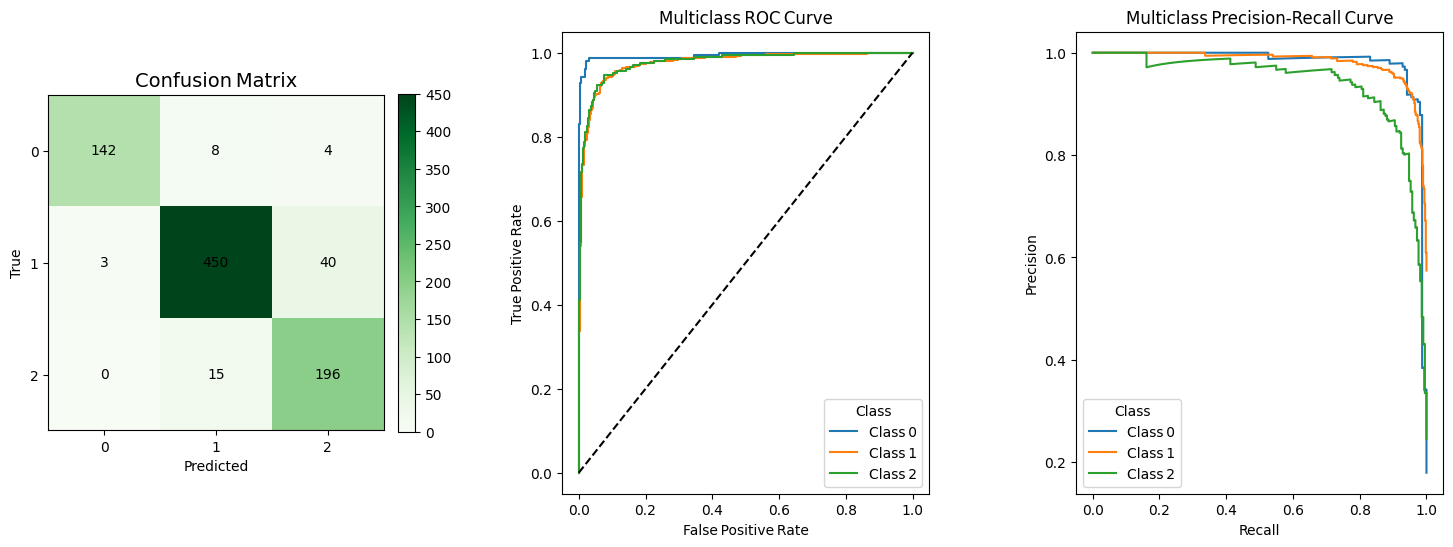

In [36]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)


# ===============================================================
# 1️⃣ Run the model on the test set
# ===============================================================
def run_secnet_test(model, test_dataloader, device):
    """
    Inference loop for SECNet that returns predictions, probabilities,
    and optional attention/uncertainty maps.
    """
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    attn_maps, uncertainty_maps = [], []

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Evaluating SECNet"):
            images, labels = batch
            images = images.to(device)
            labels = labels.to(device)

            # SECNet forward: 5-return signature
            logits, cur_attns, uncertainty_map, logits_cf, mods = model(images)

            probs = F.softmax(logits, dim=1)
            preds = torch.argmax(probs, dim=1)

            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())
            y_prob.append(probs.cpu().numpy())

            attn_maps.append({k: v for k, v in cur_attns.items()})
            uncertainty_maps.append(
                uncertainty_map.cpu().numpy() if uncertainty_map is not None else None
            )

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)
    y_prob = np.concatenate(y_prob, axis=0)

    return y_true, y_pred, y_prob, attn_maps, uncertainty_maps


# ===============================================================
# 2️⃣ Compute quantitative metrics
# ===============================================================
def evaluate_model(y_true, y_pred, y_prob=None, pos_label=1):
    """
    Calculates precision, recall, F1, kappa, sensitivity, specificity,
    class-wise F1, AUROC, and AUPRC.
    """
    classes = np.unique(y_true)
    n_classes = len(classes)
    cm = confusion_matrix(y_true, y_pred, labels=classes)

    sens_vals, spec_vals = [], []
    for i, c in enumerate(classes):
        TP_i = cm[i, i]
        FN_i = cm[i, :].sum() - TP_i
        FP_i = cm[:, i].sum() - TP_i
        TN_i = cm.sum() - (TP_i + FN_i + FP_i)
        sens_vals.append(TP_i / (TP_i + FN_i + 1e-8))
        spec_vals.append(TN_i / (TN_i + FP_i + 1e-8))

    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    class_f1 = f1_score(y_true, y_pred, average=None, labels=classes)

    # AUROC and AUPRC
    auroc, auprc = None, None
    if y_prob is not None:
        try:
            if n_classes == 2:
                y_prob_pos = y_prob if y_prob.ndim == 1 else y_prob[:, pos_label]
                auroc = roc_auc_score(y_true, y_prob_pos)
                auprc = average_precision_score(y_true, y_prob_pos)
            else:
                auroc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
                auprc = average_precision_score(
                    pd.get_dummies(y_true, columns=classes), y_prob, average="weighted"
                )
        except Exception as e:
            print(f"[WARN] AUROC/AUPRC computation failed: {e}")

    metrics_dict = {
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1,
        "Kappa": kappa,
        "Sensitivity_mean": np.mean(sens_vals),
        "Specificity_mean": np.mean(spec_vals),
        "AUROC": auroc,
        "AUPRC": auprc,
    }
    for i, c in enumerate(classes):
        metrics_dict[f"F1_class_{c}"] = class_f1[i]
        metrics_dict[f"Sensitivity_class_{c}"] = sens_vals[i]
        metrics_dict[f"Specificity_class_{c}"] = spec_vals[i]

    metrics_df = pd.DataFrame(metrics_dict, index=["SECNet_Eval"])
    return metrics_df, cm


# ===============================================================
# 3️⃣ Visual plots: Confusion Matrix + ROC + PR
# ===============================================================
def plot_confusion_and_curves(cm, y_true, y_prob, class_names=None, save_dir="figures"):
    """
    Draws confusion matrix + ROC + PR curves, saving each plot separately
    in high-quality resolution.
    """

    os.makedirs(save_dir, exist_ok=True)

    n_classes = cm.shape[0]
    if class_names is None:
        class_names = [str(i) for i in range(n_classes)]

    # --------------------------------------------------  
    # 1️⃣ Confusion Matrix  
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(cm, cmap="Greens")
    ax.set_title("Confusion Matrix", fontsize=16)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for i in range(n_classes):
        for j in range(n_classes):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

    ax.set_xticks(np.arange(n_classes))
    ax.set_xticklabels(class_names)
    ax.set_yticks(np.arange(n_classes))
    ax.set_yticklabels(class_names)

    plt.tight_layout()

    # Save high resolution
    fig.savefig(f"{save_dir}/confusion_matrix.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{save_dir}/confusion_matrix.pdf", bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------  
    # 2️⃣ ROC Curve  
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    if n_classes == 2:
        y_prob_pos = y_prob[:, 1]
        fpr, tpr, _ = roc_curve(y_true, y_prob_pos)
        ax.plot(fpr, tpr, lw=2)
        ax.plot([0, 1], [0, 1], "k--", lw=1)
        ax.set_title("ROC Curve", fontsize=16)
    else:
        for i in range(n_classes):
            y_true_bin = (y_true == i).astype(int)
            fpr, tpr, _ = roc_curve(y_true_bin, y_prob[:, i])
            ax.plot(fpr, tpr, lw=2, label=f"Class {i}")
        ax.legend(title="Class")
        ax.set_title("Multiclass ROC Curve", fontsize=16)

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    plt.tight_layout()

    fig.savefig(f"{save_dir}/ROC_curve.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{save_dir}/ROC_curve.pdf", bbox_inches="tight")
    plt.close(fig)

    # --------------------------------------------------  
    # 3️⃣ Precision–Recall Curve  
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 6))

    if n_classes == 2:
        y_prob_pos = y_prob[:, 1]
        precision, recall, _ = precision_recall_curve(y_true, y_prob_pos)
        ax.plot(recall, precision, lw=2)
        ax.set_title("Precision–Recall Curve", fontsize=16)
    else:
        for i in range(n_classes):
            y_true_bin = (y_true == i).astype(int)
            precision, recall, _ = precision_recall_curve(y_true_bin, y_prob[:, i])
            ax.plot(recall, precision, lw=2, label=f"Class {i}")
        ax.legend(title="Class")
        ax.set_title("Multiclass Precision–Recall Curve", fontsize=16)

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    plt.tight_layout()

    fig.savefig(f"{save_dir}/PR_curve.png", dpi=600, bbox_inches="tight")
    fig.savefig(f"{save_dir}/PR_curve.pdf", bbox_inches="tight")
    plt.close(fig)

    print(f"\n✔ Figures saved in: {save_dir}/")


# ===============================================================
# 4️⃣ Execute full analysis
# ===============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

y_true, y_pred, y_prob, attn_maps, uncertainty_maps = run_secnet_test(model, test_loader, device)
metrics, cm = evaluate_model(y_true, y_pred, y_prob)

print("\n=== SECNet Evaluation Metrics ===")
print(metrics.T)
print("\nConfusion Matrix:\n", cm)

plot_confusion_and_curves(cm, y_true, y_prob)
